In [ ]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

In [ ]:
# ============================================================
# CELL 2 — Load the shared clean baseline
# ============================================================
df_clean = pd.read_csv("team17_clean_baseline.csv")
print(df_clean.shape)
print(df_clean["class"].unique())   # sanity check the label spelling



(45222, 15)
['<=50K' '>50K']


In [ ]:
# ============================================================
# CELL 3 — Bootstrap helper (NEW)
# Resamples the test predictions many times to see how much
# F1 naturally jitters, giving a 95% confidence interval.
# ============================================================
def bootstrap_f1(y_true, y_pred, n=1000, seed=0):
    rng = np.random.default_rng(seed)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), len(y_true))
        scores.append(f1_score(y_true[idx], y_pred[idx], pos_label=">50K"))
    return np.percentile(scores, [2.5, 97.5])



In [ ]:
# ============================================================
# CELL 4 — The main experiment function
# ============================================================
def run_experiment(missing_rate):
    # 1. Fresh copy each time so conditions don't leak into each other
    df_exp = df_clean.copy()

    # 2. Same seed + same permutation for everyone -> nested missingness
    np.random.seed(42)
    idx = np.random.permutation(df_exp.index)
    n_missing = int(missing_rate * len(df_exp))
    df_exp.loc[idx[:n_missing], "occupation"] = np.nan

    # 3. Features / target
    X = df_exp.drop(columns="class")
    y = df_exp["class"]

    num_cols = X.select_dtypes(include="number").columns
    cat_cols = X.select_dtypes(exclude="number").columns

    # 4. Preprocessing + model pipeline
    pre = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ])

    model = Pipeline([
        ("pre", pre),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ])

    # 5. Same split for everyone
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y)

    # 6. Fit and predict
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    # 7. Bootstrap confidence interval for F1 (NEW)
    ci_lo, ci_hi = bootstrap_f1(y_te, pred)

    # 8. Print details for this condition
    print(f"\n=== {int(missing_rate*100)}% missing ===")
    print(classification_report(y_te, pred))
    print("Confusion matrix [rows=true, cols=pred], labels=[<=50K, >50K]:")
    print(confusion_matrix(y_te, pred, labels=["<=50K", ">50K"]))
    print(f"F1 (>50K) 95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")

    # 9. Return everything as one row of results
    return {
        "missing_%": int(missing_rate * 100),
        "accuracy": accuracy_score(y_te, pred),
        "precision_>50K": precision_score(y_te, pred, pos_label=">50K"),
        "recall_>50K": recall_score(y_te, pred, pos_label=">50K"),
        "f1_>50K": f1_score(y_te, pred, pos_label=">50K"),
        "f1_ci_low": ci_lo,
        "f1_ci_high": ci_hi,
    }



In [ ]:
# ============================================================
# CELL 5 — Run all four conditions
# ============================================================
results = pd.DataFrame([run_experiment(r) for r in [0.0, 0.1, 0.2, 0.3,0.4,0.5,0.6]])
print("\n=== Summary table ===")
print(results.round(4))

# Save so your teammates can use the exact same numbers
results.to_csv("team17_results.csv", index=False)




=== 0% missing ===
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      6803
        >50K       0.73      0.60      0.66      2242

    accuracy                           0.85      9045
   macro avg       0.80      0.76      0.78      9045
weighted avg       0.84      0.85      0.84      9045

Confusion matrix [rows=true, cols=pred], labels=[<=50K, >50K]:
[[6311  492]
 [ 901 1341]]
F1 (>50K) 95% CI: [0.6407, 0.6741]

=== 10% missing ===
              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      6803
        >50K       0.73      0.59      0.65      2242

    accuracy                           0.84      9045
   macro avg       0.80      0.76      0.77      9045
weighted avg       0.84      0.84      0.84      9045

Confusion matrix [rows=true, cols=pred], labels=[<=50K, >50K]:
[[6305  498]
 [ 922 1320]]
F1 (>50K) 95% CI: [0.6323, 0.6668]

=== 20% missing ===
              precision    recall 

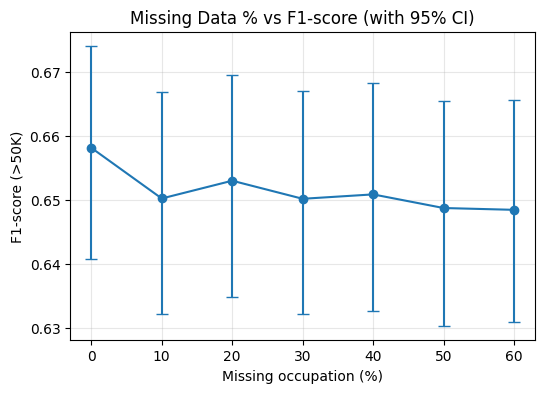

In [ ]:
# ============================================================
# CELL 6 — Graph 1: Missing Data % vs F1-score, with error bars
# ============================================================
plt.figure(figsize=(6, 4))
plt.errorbar(
    results["missing_%"], results["f1_>50K"],
    yerr=[results["f1_>50K"] - results["f1_ci_low"],
          results["f1_ci_high"] - results["f1_>50K"]],
    marker="o", capsize=4
)
plt.xlabel("Missing occupation (%)")
plt.ylabel("F1-score (>50K)")
plt.title("Missing Data % vs F1-score (with 95% CI)")
plt.xticks(results["missing_%"])
plt.grid(True, alpha=0.3)
plt.savefig("figure1_f1_vs_missing.png", dpi=150, bbox_inches="tight")
plt.show()


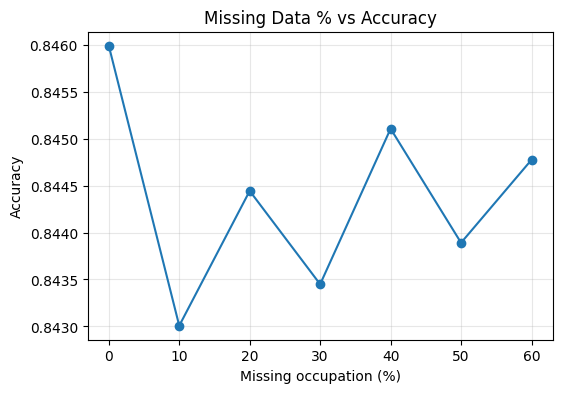

In [ ]:

# ============================================================
# CELL 7 — Graph 2: Missing Data % vs Accuracy
# ============================================================
plt.figure(figsize=(6, 4))
plt.plot(results["missing_%"], results["accuracy"], marker="o")
plt.xlabel("Missing occupation (%)")
plt.ylabel("Accuracy")
plt.title("Missing Data % vs Accuracy")
plt.xticks(results["missing_%"])
plt.grid(True, alpha=0.3)
plt.savefig("figure2_accuracy_vs_missing.png", dpi=150, bbox_inches="tight")
plt.show()